# Toy Store Ecommerce Database Analysis

In this project, we'll analyze the e-commerce database for a toy store, which includes information on orders, products, website sessions, page views, and refunds.

Specifically, we'll evaluate which products bring the most revenue and profit, evaluate the key metrics of the toy store's website performance, and try to identify the most common reasons for order refunds.

The original dataset is publicly available on [Maven Analytics](https://mavenanalytics.io/data-playground/toy-store-e-commerce-database).

## Part 1: Importing the Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import prettytable
prettytable.DEFAULT = 'DEFAULT'
%load_ext sql
%matplotlib inline

In [2]:
orders = pd.read_csv('orders.csv')
products = pd.read_csv('products.csv')
web_sessions = pd.read_csv('website_sessions.csv')
web_pageviews = pd.read_csv('website_pageviews.csv')
refunds = pd.read_csv('order_item_refunds.csv')
order_items = pd.read_csv('order_items.csv')
dictionary = pd.read_csv('maven_fuzzy_factory_data_dictionary.csv')

In [3]:
dictionary

,Table,Field,Description
0,orders,order_id,Unique identifier for each order (PK)
1,orders,created_at,Timestamp when the order was placed
2,orders,website_session_id,Unique identifier for the website session (FK)
3,orders,user_id,Unique identifier for the user (FK)
4,orders,primary_product_id,Unique identifier for the primary product in t...
5,orders,items_purchased,Number of items in the order
6,orders,price_usd,Total price for the items in the order
7,orders,cogs_usd,Cost of goods sold for the items in the order
8,order_items,order_item_id,Unique identifier for each order item (PK)
9,order_items,created_at,Timestamp when the order was placed


## Part 2: Data Wrangling

Before we begin our analysis, we must ensure the data in the tables is clean, reliable, and accurate. We'll start with the orders table.

In [4]:
orders.head()

,order_id,created_at,website_session_id,user_id,primary_product_id,items_purchased,price_usd,cogs_usd
0,1,2012-03-19 10:42:46,20,20,1,1,49.99,19.49
1,2,2012-03-19 19:27:37,104,104,1,1,49.99,19.49
2,3,2012-03-20 06:44:45,147,147,1,1,49.99,19.49
3,4,2012-03-20 09:41:45,160,160,1,1,49.99,19.49
4,5,2012-03-20 11:28:15,177,177,1,1,49.99,19.49


In [5]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32313 entries, 0 to 32312
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            32313 non-null  int64  
 1   created_at          32313 non-null  object 
 2   website_session_id  32313 non-null  int64  
 3   user_id             32313 non-null  int64  
 4   primary_product_id  32313 non-null  int64  
 5   items_purchased     32313 non-null  int64  
 6   price_usd           32313 non-null  float64
 7   cogs_usd            32313 non-null  float64
dtypes: float64(2), int64(5), object(1)
memory usage: 2.0+ MB


In [6]:
orders['created_at'] = pd.to_datetime(orders['created_at'])
orders.describe(include='all')

,order_id,created_at,website_session_id,user_id,primary_product_id,items_purchased,price_usd,cogs_usd
count,32313.000000,32313,32313.000000,32313.000000,32313.000000,32313.000000,32313.000000,32313.000000
mean,16157.000000,2014-04-14 03:01:01.276823552,258292.288707,215691.622629,1.392474,1.238666,59.991636,22.355406
min,1.000000,2012-03-19 10:42:46,20.000000,13.000000,1.000000,1.000000,29.990000,9.490000
25%,8079.000000,2013-10-30 14:30:35,144828.000000,124135.000000,1.000000,1.000000,49.990000,19.490000
50%,16157.000000,2014-06-11 14:27:02,263554.000000,221461.000000,1.000000,1.000000,49.990000,19.490000
75%,24235.000000,2014-11-28 10:53:48,374799.000000,310542.000000,2.000000,1.000000,59.990000,22.490000
max,32313.000000,2015-03-19 05:38:31,472818.000000,394273.000000,4.000000,2.000000,109.980000,41.980000
std,9328.103961,NaN,132427.649842,108402.203189,0.732277,0.426274,17.808771,6.238621


As we can see, there are no other errors, outliers, or inconsistencies in this table. Let's move on to the order_items table.

In [7]:
order_items.head()

,order_item_id,created_at,order_id,product_id,is_primary_item,price_usd,cogs_usd
0,1,2012-03-19 10:42:46,1,1,1,49.99,19.49
1,2,2012-03-19 19:27:37,2,1,1,49.99,19.49
2,3,2012-03-20 06:44:45,3,1,1,49.99,19.49
3,4,2012-03-20 09:41:45,4,1,1,49.99,19.49
4,5,2012-03-20 11:28:15,5,1,1,49.99,19.49


In [8]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40025 entries, 0 to 40024
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   order_item_id    40025 non-null  int64  
 1   created_at       40025 non-null  object 
 2   order_id         40025 non-null  int64  
 3   product_id       40025 non-null  int64  
 4   is_primary_item  40025 non-null  int64  
 5   price_usd        40025 non-null  float64
 6   cogs_usd         40025 non-null  float64
dtypes: float64(2), int64(4), object(1)
memory usage: 2.1+ MB


In [9]:
order_items['created_at'] = pd.to_datetime(order_items['created_at'])
order_items.describe(include='all')

,order_item_id,created_at,order_id,product_id,is_primary_item,price_usd,cogs_usd
count,40025.000000,40025,40025.000000,40025.000000,40025.000000,40025.000000,40025.000000
mean,20013.000000,2014-05-13 10:24:45.947732736,17121.957502,1.770019,0.807320,48.432473,18.047976
min,1.000000,2012-03-19 10:42:46,1.000000,1.000000,0.000000,29.990000,9.490000
25%,10007.000000,2013-12-25 23:27:19,9871.000000,1.000000,1.000000,49.990000,19.490000
50%,20013.000000,2014-07-14 15:31:31,17490.000000,1.000000,1.000000,49.990000,19.490000
75%,30019.000000,2014-12-01 16:41:10,24818.000000,2.000000,1.000000,49.990000,19.490000
max,40025.000000,2015-03-19 05:38:31,32313.000000,4.000000,1.000000,59.990000,22.490000
std,11554.366599,NaN,9053.765867,1.085561,0.394408,8.012370,3.856821


Again, no significant errors or outliers. Let's move on to the order refunds table.

In [10]:
refunds.head()

,order_item_refund_id,created_at,order_item_id,order_id,refund_amount_usd
0,1,2012-04-06 11:32:43,57,57,49.99
1,2,2012-04-13 01:09:43,74,74,49.99
2,3,2012-04-15 07:03:48,71,71,49.99
3,4,2012-04-17 20:00:37,118,118,49.99
4,5,2012-04-22 20:53:49,116,116,49.99


In [11]:
refunds['created_at'] = pd.to_datetime(refunds['created_at'])
refunds.describe(include='all')

,order_item_refund_id,created_at,order_item_id,order_id,refund_amount_usd
count,1731.000000,1731,1731.000000,1731.000000,1731.000000
mean,866.000000,2014-04-15 01:36:59.684575488,18472.214905,15868.242057,49.300225
min,1.000000,2012-04-06 11:32:43,57.000000,57.000000,29.990000
25%,433.500000,2013-10-08 01:09:57,7417.000000,7412.000000,49.990000
50%,866.000000,2014-07-19 21:00:07,19858.000000,17375.000000,49.990000
75%,1298.500000,2014-11-11 11:12:48,26900.000000,22539.500000,49.990000
max,1731.000000,2015-04-01 18:11:08,39950.000000,32255.000000,59.990000
std,499.840975,NaN,11438.074606,9096.061945,4.956015


In [12]:
products.head()

,product_id,created_at,product_name
0,1,2012-03-19 08:00:00,The Original Mr. Fuzzy
1,2,2013-01-06 13:00:00,The Forever Love Bear
2,3,2013-12-12 09:00:00,The Birthday Sugar Panda
3,4,2014-02-05 10:00:00,The Hudson River Mini bear


In [13]:
products['created_at'] = pd.to_datetime(products['created_at'])

In [14]:
web_sessions.head()

,website_session_id,created_at,user_id,is_repeat_session,utm_source,utm_campaign,utm_content,device_type,http_referer
0,1,2012-03-19 08:04:16,1,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com
1,2,2012-03-19 08:16:49,2,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com
2,3,2012-03-19 08:26:55,3,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com
3,4,2012-03-19 08:37:33,4,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com
4,5,2012-03-19 09:00:55,5,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com


In [15]:
web_sessions['created_at'] = pd.to_datetime(web_sessions['created_at'])
web_sessions.describe(include='int64')

,website_session_id,user_id,is_repeat_session
count,472871.000000,472871.000000,472871.000000
mean,236436.000000,198037.970163,0.166119
std,136506.243908,111992.997798,0.372188
min,1.000000,1.000000,0.000000
25%,118218.500000,101966.500000,0.000000
50%,236436.000000,199483.000000,0.000000
75%,354653.500000,294433.000000,0.000000
max,472871.000000,394318.000000,1.000000


In [16]:
object_cols = web_sessions.select_dtypes(include='object').columns
for obj in object_cols:
  print(web_sessions[obj].value_counts())
  print()

utm_source
gsearch       316035
bsearch        62823
socialbook     10685
Name: count, dtype: int64

utm_campaign
nonbrand            337615
brand                41243
desktop_targeted      5590
pilot                 5095
Name: count, dtype: int64

utm_content
g_ad_1         282706
b_ad_1          54909
g_ad_2          33329
b_ad_2           7914
social_ad_2      5590
social_ad_1      5095
Name: count, dtype: int64

device_type
desktop    327027
mobile     145844
Name: count, dtype: int64

http_referer
https://www.gsearch.com       351237
https://www.bsearch.com        71032
https://www.socialbook.com     10685
Name: count, dtype: int64



We have the last table left to check and clean: website pageviews.

In [17]:
web_pageviews.head()

,website_pageview_id,created_at,website_session_id,pageview_url
0,1,2012-03-19 08:04:16,1,/home
1,2,2012-03-19 08:16:49,2,/home
2,3,2012-03-19 08:26:55,3,/home
3,4,2012-03-19 08:37:33,4,/home
4,5,2012-03-19 09:00:55,5,/home


In [18]:
web_pageviews['created_at'] = pd.to_datetime(web_pageviews['created_at'])
web_pageviews.describe(include='int64')

,website_pageview_id,website_session_id
count,1.188124e+06,1.188124e+06
mean,5.940625e+05,2.444585e+05
std,3.429820e+05,1.356199e+05
min,1.000000e+00,1.000000e+00
25%,2.970318e+05,1.277860e+05
50%,5.940625e+05,2.478080e+05
75%,8.910932e+05,3.627390e+05
max,1.188124e+06,4.728710e+05


In [19]:
print(web_pageviews['pageview_url'].value_counts())

pageview_url
/products                      261231
/the-original-mr-fuzzy         162525
/home                          137576
/lander-2                      131170
/cart                           94953
/lander-3                       79000
/lander-5                       68166
/shipping                       64484
/billing-2                      48441
/lander-1                       47574
/thank-you-for-your-order       32313
/the-forever-love-bear          26033
/the-birthday-sugar-panda       19046
/lander-4                        9385
/billing                         3617
/the-hudson-river-mini-bear      2610
Name: count, dtype: int64


Now that we've wrangled our data and ensured it is in a reliable state, we can move on to answering key questions related to the toy store.

## Part 3: Exploratory Data Analysis

In this analysis, we'll try to answer the following questions:
- Which marketing channels are the most effective at attracting traffic?
- What is the most ordered and profitable plush bear offered by the toy store?
- What items are refunded most often?
- How did orders and their frequency evolve over time?
- How often do visitors return to the toy store website?

In [20]:
con = sqlite3.connect('toy_store.db')
%sql sqlite:///toy_store.db

In [21]:
orders.to_sql('orders', con, if_exists='replace', index=False)
products.to_sql('products', con, if_exists='replace', index=False)
refunds.to_sql('refunds', con, if_exists='replace', index=False)
order_items.to_sql('order_items', con, if_exists='replace', index=False)
web_sessions.to_sql('web_sessions', con, if_exists='replace', index=False)
web_pageviews.to_sql('web_pageviews', con, if_exists='replace', index=False)

1188124

In [22]:
%%sql
select utm_source, device_type, count(*) as num_of_sessions
from web_sessions
group by utm_source, device_type
order by num_of_sessions desc

 * sqlite:///toy_store.db
Done.


utm_source,device_type,num_of_sessions
gsearch,desktop,215077
gsearch,mobile,100958
bsearch,desktop,54262
None,desktop,51576
None,mobile,31752
bsearch,mobile,8561
socialbook,desktop,6112
socialbook,mobile,4573


The most effective traffic source is gserach, with over 350000 sessions initiating from this search engine.

Additionally, more than half of the website's visitors are desktop users.

In [23]:
%%sql
select utm_source, utm_campaign, count(*) as num_of_sessions
from web_sessions
group by utm_source, utm_campaign
order by num_of_sessions desc

 * sqlite:///toy_store.db
Done.


utm_source,utm_campaign,num_of_sessions
gsearch,nonbrand,282706
None,None,83328
bsearch,nonbrand,54909
gsearch,brand,33329
bsearch,brand,7914
socialbook,desktop_targeted,5590
socialbook,pilot,5095


Based on query results, engagement and click-through are higher when ad campaigns are nonbranded. This is likely because people currently find the products themselves more recognizable and appealing than the brand itself.

In [24]:
%%sql
select
  s.utm_content,
  p.pageview_url,
  count(*) as number_of_views
from
  web_sessions s
join web_pageviews p
on p.website_session_id = s.website_session_id
group by
  utm_content,
  pageview_url
order by number_of_views desc
limit 20

 * sqlite:///toy_store.db
Done.


utm_content,pageview_url,number_of_views
g_ad_1,/products,155823
g_ad_1,/lander-2,100982
g_ad_1,/the-original-mr-fuzzy,97413
None,/home,83328
g_ad_1,/lander-3,68249
g_ad_1,/cart,56148
g_ad_1,/lander-5,54873
None,/products,50082
g_ad_1,/lander-1,38115
g_ad_1,/shipping,37961


- Based on the query results, most website visitors came from g_ad_1.
- The 3 most popular landing pages are lander-2, lander-3, and lander-5.

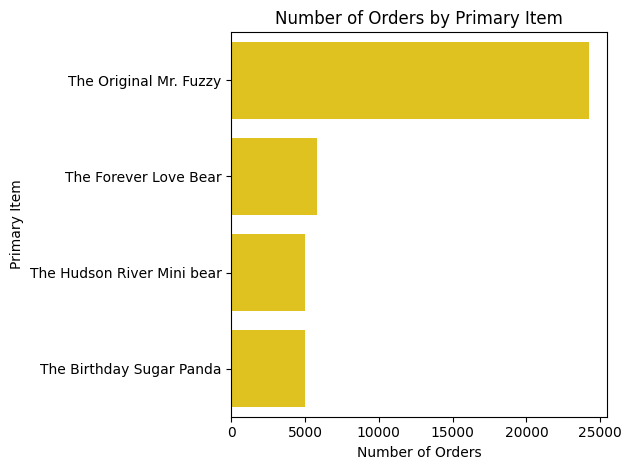

In [34]:
query = """
select
  p.product_name as primary_item,
  count(*) as number_of_orders
from orders o
join order_items oi
on o.order_id = oi.order_id
join products p
on p.product_id = oi.product_id
group by primary_item
order by number_of_orders desc
"""
query_res = pd.read_sql(query, con)
sns.barplot(x='number_of_orders', y='primary_item', data=query_res, color='gold')
plt.title('Number of Orders by Primary Item')
plt.xlabel('Number of Orders')
plt.ylabel('Primary Item')
plt.tight_layout()
plt.show()

In [26]:
%%sql
select
  p.product_name,
  oi.price_usd as price,
  round(sum(o.price_usd - o.cogs_usd), 2) as total_profit
from products p
join order_items oi
on p.product_id = oi.product_id
join orders o
on o.order_id = oi.order_id
where
  oi.is_primary_item = 1
group by product_name
order by total_profit desc

 * sqlite:///toy_store.db
Done.


product_name,price,total_profit
The Original Mr. Fuzzy,49.99,879952.0
The Forever Love Bear,59.99,200348.0
The Birthday Sugar Panda,45.99,122410.5
The Hudson River Mini bear,29.99,13429.0


As we can see, The Original Mr. Fuzzy sales account for over 70% of the company's profit. This means that this product is reliable, and marketing efforts should thus focus on promoting this bear.

In [27]:
%%sql
select
  p.product_name,
  count(*) as num_of_refunds
from
  refunds r
join order_items oi
on oi.order_item_id = r.order_item_id
join products p
on p.product_id = oi.product_id
group by product_name
order by num_of_refunds desc

 * sqlite:///toy_store.db
Done.


product_name,num_of_refunds
The Original Mr. Fuzzy,1237
The Birthday Sugar Panda,301
The Forever Love Bear,129
The Hudson River Mini bear,64


- By absolute amounts, the most refunded item is the Original Mr. Fuzzy.
  - This makes sense, as it is also the most ordered plush bear out of all.
- It is worth noting that, despite bringing less profit than the Forever Love Bear, the Birthday Sugar Panda as refunded almost thrice more frequently than the Forever Love Bear.
  - This suggests that there could be quality issue with this toy model worth checking.

In [28]:
%%sql
select
  strftime('%Y %m', created_at) as order_date,
  count(*) as number_of_orders
from orders
group by order_date
order by order_date

 * sqlite:///toy_store.db
Done.


order_date,number_of_orders
2012 03,60
2012 04,99
2012 05,108
2012 06,140
2012 07,169
2012 08,228
2012 09,287
2012 10,371
2012 11,618
2012 12,506


Based on the table , the number of plush bears has risen over the last three years, though there is a fall in number of orders between March and February of 2015.

Because we know the general trajectory and time-series data including both years and months is hard to visualize properly, we'll visualize the number of orders by months.

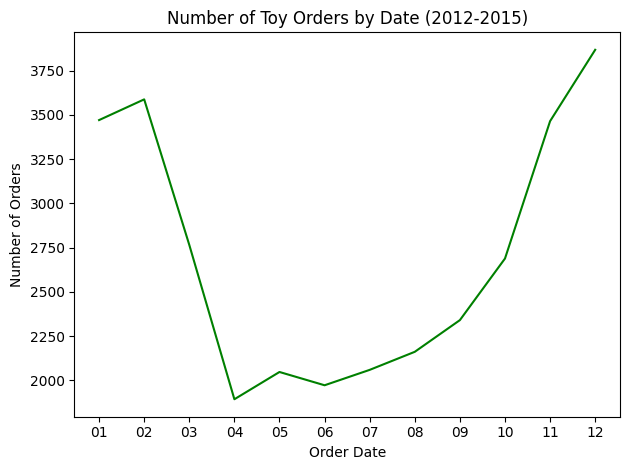

In [31]:
query = """
select
  strftime('%m', created_at) as order_date,
  count(*) as number_of_orders
from orders
group by order_date
order by order_date
"""
query_res = pd.read_sql_query(query, con)
sns.lineplot(x='order_date', y='number_of_orders', data = query_res, color = 'green')
plt.title('Number of Toy Orders by Date (2012-2015)')
plt.xlabel('Order Date')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

We have just uncovered a key insight about sales: demand for the toy store's plush bears is the highest in late autumn and winter months, from October to February included.

This means that, for maximum efficiency, the company should scale down its operations in other months and boost ad campaign frequency in late autumn and winter.

In [30]:
%%sql
select
  round(
    cast(
      (select count(*)
      from web_sessions
      where is_repeat_session = 1)
    as real) / count(*), 2) as repeat_session_rate
from web_sessions

 * sqlite:///toy_store.db
Done.


repeat_session_rate
0.17


Only 17% of visitors who have visited the toy store site at least once return again.
This suggests that customer retention is low and could be increased for greater profits.

## Conclusions

Based on the analysis conducted above, here are the key insights uncovered from the e-commerce database:
- The most sold and profitable toy is the Original Mr. Fuzzy bear.
- The most relatively returned item is the Birthday Sugar Panda, which suggests that there are issues with the product that could be further studied.
- Most website visitors come from gsearch and use desktop.
- Additionally, the most effective ad campaign by far is g_ad_1.
  - The most popular landing pages are lander-2, lander-3, and lander-5, and most visitors come from nonbranded ad campaigns.
- Most toy sales consistently occur between October and February.
- The repeat session rate is around 17%.

**Next practical steps:**
- Scale back marketing and production in spring and summer, then re-expand in winter and autumn, focusing on capturing gsearch users using the g_ad_1 ad.
- Focus the majority of advertising on promoting the Original Mr. Fuzzy.
- Assess the quality of Birthday Sugar Panda and survey customers on their experience with this product to uncover key complaints.